In [224]:
import numpy as np
import scipy
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt

import odrpack as odr

from uncertainties import ufloat
from uncertainties import umath
from uncertainties import unumpy as un

In [225]:
df = pd.read_excel("p4electro.xlsx", sheet_name="h1input", decimal = ",")

In [226]:
X = un.uarray(df["I(A)"],df["dI"])
Y = un.uarray(df["B(mT)"],df["dB"])

In [227]:
#=============================== Blocón de ODR_FIT ===============================

def func(x, beta):
    return beta[0] * x + beta[1]

beta0 = [-1.6e-3,-4.81e05]

fittingX = un.nominal_values(X)
fittingY = un.nominal_values(Y)
fittingXUncertainty = un.std_devs(X)
fittingYUncertainty = un.std_devs(Y)

sol = odr.odr_fit(func, fittingX, fittingY, beta0, weight_x = 1/(fittingXUncertainty**2), weight_y = 1/(fittingYUncertainty**2))

pendiente = ufloat(sol.beta[0],np.sqrt(sol.cov_beta[0,0]))
ordenada = ufloat(sol.beta[1],np.sqrt(sol.cov_beta[1,1]))

print("pendiente = {:.3f}".format(pendiente))
print("ordenada = {:.3f}".format(ordenada))

print(f"χ² reducido = {sol.sum_square/(len(un.nominal_values(X))-len(sol.beta))}")
#print(f"pearson = {scipy.stats.pearsonr(fittingX, fittingY).statistic}")
print(f"R² = {scipy.stats.pearsonr(fittingX, fittingY).statistic**2}")

#=================================================================================

pendiente = -1.627+/-0.087
ordenada = -0.046+/-0.086
χ² reducido = 0.006582348202933776
R² = 0.9996741192143929


In [228]:
mu0 = 4*np.pi*10**-7
N = 200
a = ufloat(10.5e-2, 0.1e-2)
kMedido = pendiente

kTeorico = 8/(5 * np.sqrt(5)) * N*mu0/a * 1000 #en mT/A

C = - kTeorico / kMedido

print("K teorico = {:.3f}".format(kTeorico))
print("K medido = {:.3f}".format(kMedido))

print("Constante C = {:.3f}".format(C))

K teorico = 1.713+/-0.016
K medido = -1.627+/-0.087
Constante C = 1.053+/-0.057


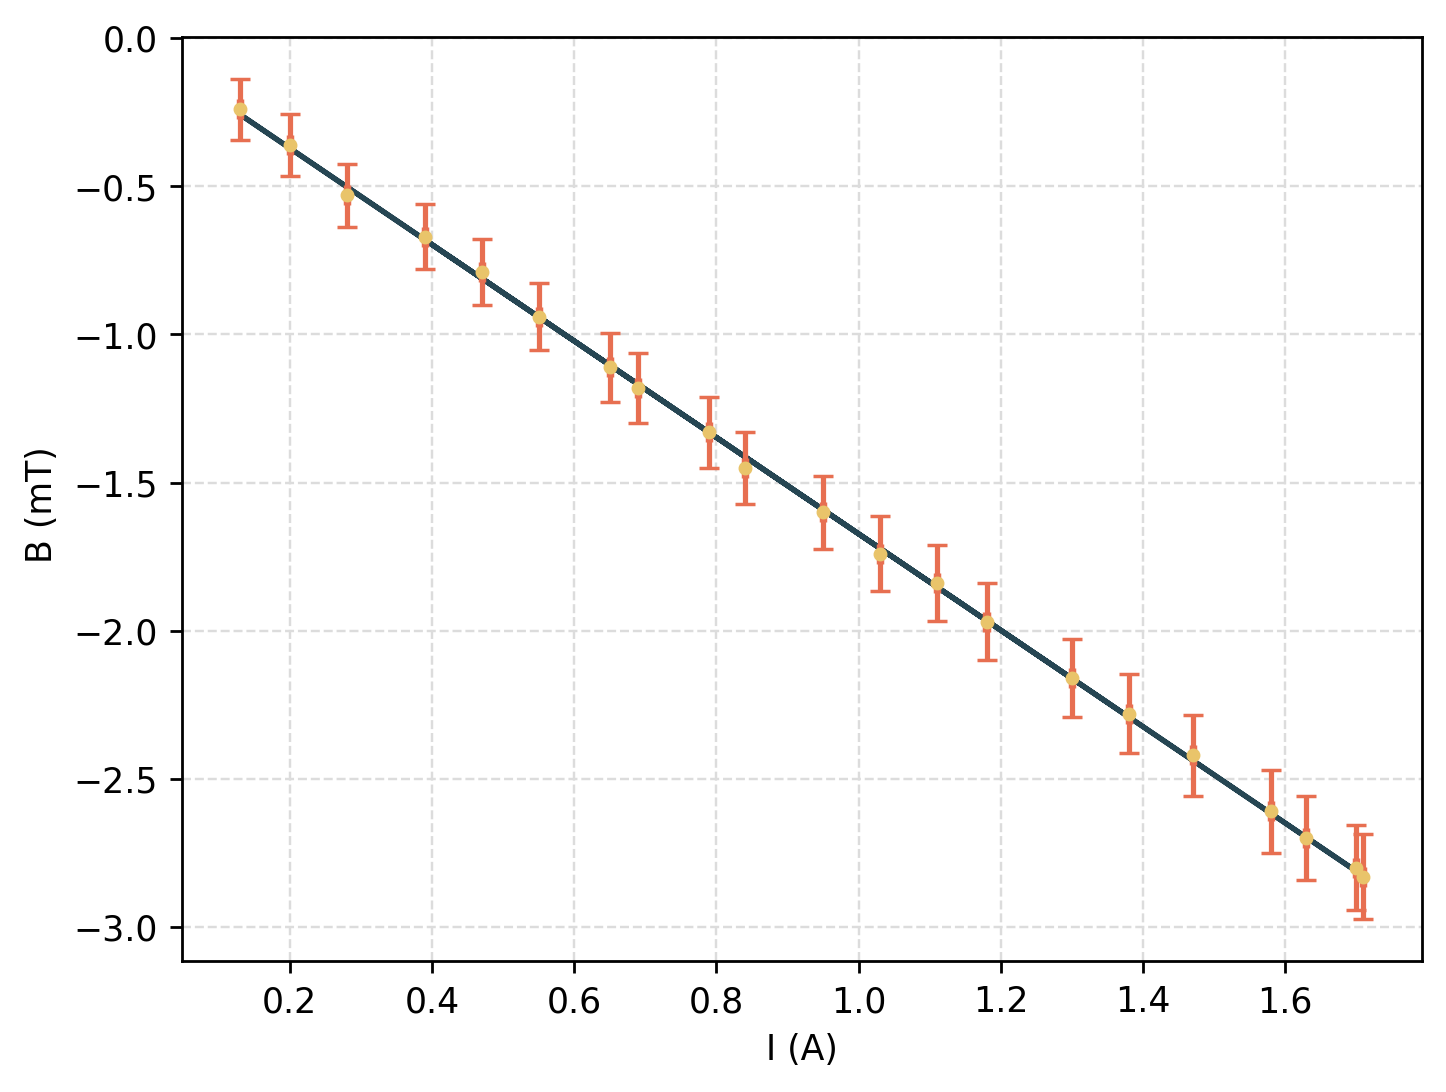

In [247]:
fig, ax = plt.subplots(dpi = 250)

ax.errorbar(un.nominal_values(X),un.nominal_values(Y), un.std_devs(X), un.std_devs(Y), color = "#e9c46a", fmt = ".", ecolor = "#e76f51", capsize=3, zorder = 10)

ax.plot(un.nominal_values(X), func(un.nominal_values(X), sol.beta), color = "#264653")

ax.set(xlabel = "I (A)", ylabel = "B (mT) ")

ax.grid(zorder=0,color='gainsboro', linestyle='--', linewidth=0.7)

plt.savefig("calibracion.png", bbox_inches = "tight")

plt.show()